# Projeto Final — Machine Learning e Visão Computacional

## Predição de Risco de Crédito

### Objetivo do projeto

Este projeto tem como objetivo desenvolver um pipeline completo de Machine Learning capaz de prever o risco de inadimplência de clientes de uma instituição financeira.

A variável alvo utilizada será `loan_status`:

- `0`: cliente adimplente;
- `1`: cliente inadimplente.

O desenvolvimento seguirá as seguintes etapas:

1. Coleta de Dados
2. Limpeza Estrutural e Exploração
3. Divisão dos Dados
4. Pré-processamento
5. Treinamento dos Modelos
6. Avaliação e Validação

Os algoritmos avaliados serão o K-Nearest Neighbors (KNN) e a Árvore de Decisão.

# 1. Coleta de Dados

Nesta etapa serão realizadas a importação das bibliotecas, a leitura da base de dados e uma inspeção inicial do conjunto de dados.

Nenhuma transformação ou exclusão será realizada neste momento. O objetivo é apenas verificar se a base foi carregada corretamente e compreender sua estrutura inicial.

## 1.1 Importação das Bibliotecas

In [3977]:
# Manipulação e análise de dados
import pandas as pd
import numpy as np

# Visualização de dados
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações visuais
sns.set_theme(style="whitegrid")

# Configuração para exibir todas as colunas do DataFrame
pd.set_option("display.max_columns", None)

## 1.2 Carregamento da Base de Dados

A base original está armazenada na pasta `data/raw`, preservando os dados brutos sem alterações.

O arquivo será carregado com a biblioteca Pandas e armazenado em um DataFrame chamado `df`.

In [3978]:
# =====================================================
# Carregamento da base de dados
# =====================================================


# Caminho relativo do arquivo CSV
caminho_dados = "../data/raw/credit_risk_dataset.csv"

# Carregamento da base
df = pd.read_csv(caminho_dados)
print("Base carregada com sucesso!")

Base carregada com sucesso!


## 1.3 Inspeção Inicial dos Registros

In [3979]:
print("Primeiros registros:")
display(df.head())
print("Ultimos registros:")
display(df.tail())
print("Registros aleatórios:")
display(df.sample(5, random_state=42))



Primeiros registros:


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


Ultimos registros:


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26
32580,66,42000,RENT,2.0,MEDICAL,B,6475,9.99,0,0.15,N,30


Registros aleatórios:


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
14668,24,28000,OWN,6.0,HOMEIMPROVEMENT,B,10000,10.37,0,0.36,N,2
24614,27,64000,RENT,0.0,PERSONAL,C,10000,15.27,0,0.16,Y,10
11096,26,72000,MORTGAGE,10.0,EDUCATION,D,16000,NaN,0,0.22,N,3
10424,23,27996,RENT,7.0,DEBTCONSOLIDATION,A,10000,NaN,1,0.36,N,2
26007,30,44500,RENT,2.0,MEDICAL,E,13000,16.32,1,0.29,N,6


## 1.4 Dimensões do Dataset

In [3980]:
linhas, colunas = df.shape
print(f"Quantidade de linhas : {linhas}")
print(f"Quantidade de colunas: {colunas}")


Quantidade de linhas : 32581
Quantidade de colunas: 12


## 1.5 Variáveis Disponíveis

In [3981]:

for coluna in df.columns:
    print(coluna)

person_age
person_income
person_home_ownership
person_emp_length
loan_intent
loan_grade
loan_amnt
loan_int_rate
loan_status
loan_percent_income
cb_person_default_on_file
cb_person_cred_hist_length


### Primeiras observações

Após o carregamento da base foi possível verificar que o dataset contém informações relacionadas ao perfil financeiro dos clientes e às características dos empréstimos concedidos.

As variáveis incluem informações demográficas, renda anual, finalidade do empréstimo, classificação de crédito, taxa de juros e histórico financeiro.

A variável **loan_status** representa o alvo do problema de classificação, indicando se o cliente tornou-se inadimplente (1) ou permaneceu adimplente (0).

Nesta etapa foi confirmado que o arquivo foi carregado corretamente e que a estrutura da base está íntegra para prosseguirmos com a análise exploratória.

## 1.6 Auditoria Técnica Inicial

Antes de iniciar a análise exploratória é necessário compreender a estrutura interna do conjunto de dados.

Nesta etapa serão analisados:

- estrutura da base
- tipos das variáveis
- valores ausentes
- consistência dos dados

In [3982]:
df.info()



<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB


In [3983]:

df.dtypes.value_counts()
#permite prever o trabalho futuro, quantos Encoding precisaremos por exemplo

int64      5
str        4
float64    3
Name: count, dtype: int64

In [3984]:
tipos = pd.DataFrame({

"Tipo":df.dtypes,

"Nulos":df.isnull().sum(),

"Percentual Nulos":round(df.isnull().mean()*100,2)

})

tipos

,Tipo,Nulos,Percentual Nulos
person_age,int64,0,0.00
person_income,int64,0,0.00
person_home_ownership,str,0,0.00
person_emp_length,float64,895,2.75
loan_intent,str,0,0.00
loan_grade,str,0,0.00
loan_amnt,int64,0,0.00
loan_int_rate,float64,3116,9.56
loan_status,int64,0,0.00
loan_percent_income,float64,0,0.00


### Análise da Auditoria Técnica

A auditoria técnica permitiu compreender a estrutura geral do conjunto de dados.

Foi possível identificar variáveis numéricas inteiras, variáveis numéricas contínuas e variáveis categóricas.

Também foram observadas colunas contendo valores ausentes, indicando que será necessária uma etapa de tratamento antes do treinamento dos modelos.

As variáveis categóricas deverão ser convertidas para representação numérica durante a fase de pré-processamento utilizando técnicas de Encoding.

Essa inspeção confirmou que a base apresenta estrutura compatível com problemas de classificação supervisionada.

# 2. Limpeza Estrutural e Exploração dos Dados

Nesta etapa será realizada uma investigação detalhada da qualidade dos dados.

O objetivo é compreender a distribuição das variáveis, identificar inconsistências e definir quais tratamentos serão necessários antes da construção dos modelos de Machine Learning.

## 2.1 - Detecção de valores duplicados

In [3985]:
duplicados = df.duplicated().sum()

print(f"Quantidade de registros duplicados: {duplicados}")

Quantidade de registros duplicados: 165


### Investigação de Registros Duplicados

Foi realizada uma inspeção para identificar registros completamente duplicados na base de dados.

Registros duplicados podem introduzir viés estatístico, aumentando artificialmente a frequência de determinados perfis de clientes e influenciando o treinamento dos algoritmos.

Nesta etapa foi identificado o total de registros duplicados, cuja remoção será realizada apenas após a confirmação de que representam redundâncias reais.

## 2.2 - Detecção de valores Nulos

In [3986]:
nulos = pd.DataFrame({

"Quantidade":df.isnull().sum(),

"Percentual":round(df.isnull().mean()*100,2)

})

nulos

,Quantidade,Percentual
person_age,0,0.00
person_income,0,0.00
person_home_ownership,0,0.00
person_emp_length,895,2.75
loan_intent,0,0.00
loan_grade,0,0.00
loan_amnt,0,0.00
loan_int_rate,3116,9.56
loan_status,0,0.00
loan_percent_income,0,0.00


### Investigação de Valores Ausentes

Foi realizada uma inspeção para identificar a presença de valores ausentes no conjunto de dados.

Os resultados permitirão definir, posteriormente, a estratégia de tratamento mais adequada para cada variável, considerando sua distribuição estatística e o impacto no treinamento dos modelos.

Nesta etapa nenhuma imputação foi realizada, pois o objetivo é apenas compreender a qualidade dos dados.

## 2.3 Análise Descritiva e Estatística

Nesta etapa será realizada uma análise estatística das variáveis presentes no conjunto de dados.

O objetivo é compreender a dimensão da base, os tipos das variáveis, as medidas de tendência central, a dispersão dos dados, os valores mínimos e máximos e os quartis.

Essa análise será utilizada para identificar possíveis assimetrias, inconsistências e indícios de valores extremos antes da construção dos gráficos exploratórios.

### Sumário Estatístico das Variáveis Numéricas

O método `describe()` será utilizado para calcular as principais medidas estatísticas das variáveis numéricas, incluindo média, desvio-padrão, mínimo, máximo e quartis.

In [3987]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
person_age,32581.0,27.734600,6.348078,20.00,23.00,26.00,30.00,144.00
person_income,32581.0,66074.848470,61983.119168,4000.00,38500.00,55000.00,79200.00,6000000.00
person_emp_length,31686.0,4.789686,4.142630,0.00,2.00,4.00,7.00,123.00
loan_amnt,32581.0,9589.371106,6322.086646,500.00,5000.00,8000.00,12200.00,35000.00
loan_int_rate,29465.0,11.011695,3.240459,5.42,7.90,10.99,13.47,23.22
loan_status,32581.0,0.218164,0.413006,0.00,0.00,0.00,0.00,1.00
loan_percent_income,32581.0,0.170203,0.106782,0.00,0.09,0.15,0.23,0.83
cb_person_cred_hist_length,32581.0,5.804211,4.055001,2.00,3.00,4.00,8.00,30.00


### Sumário Estatístico das Variáveis Categóricas

As variáveis categóricas serão analisadas por meio da quantidade de valores preenchidos, número de categorias distintas, categoria mais frequente e frequência da categoria predominante.

In [3988]:
df.describe(include="object").T

C:\Users\maycon.valer\AppData\Local\Temp\ipykernel_10132\1274302342.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object").T


,count,unique,top,freq
person_home_ownership,32581,4,RENT,16446
loan_intent,32581,6,EDUCATION,6453
loan_grade,32581,7,A,10777
cb_person_default_on_file,32581,2,N,26836


In [3989]:
auditoria_estatistica = pd.DataFrame({
    "tipo_dado": df.dtypes,
    "quantidade_preenchida": df.notna().sum(),
    "quantidade_nulos": df.isna().sum(),
    "percentual_nulos": (df.isna().mean() * 100).round(2),
    "quantidade_unicos": df.nunique()
})

auditoria_estatistica

,tipo_dado,quantidade_preenchida,quantidade_nulos,percentual_nulos,quantidade_unicos
person_age,int64,32581,0,0.00,58
person_income,int64,32581,0,0.00,4295
person_home_ownership,str,32581,0,0.00,4
person_emp_length,float64,31686,895,2.75,36
loan_intent,str,32581,0,0.00,6
loan_grade,str,32581,0,0.00,7
loan_amnt,int64,32581,0,0.00,753
loan_int_rate,float64,29465,3116,9.56,348
loan_status,int64,32581,0,0.00,2
loan_percent_income,float64,32581,0,0.00,77


### Decisão do Cientista de Dados — Análise Descritiva e Estatística

A análise desritiva demostra como os dados realmente se apresentam, enquando a estatística demonstra como eles de relacionam entre si

A análise descritiva confirmou que o conjunto de dados possui variáveis numéricas e categóricas relacionadas ao perfil dos clientes e às características dos empréstimos.

Na Análise estaística, a comparação entre média, mediana, quartis e valores máximos revelou que algumas variáveis apresentam valores máximos muito superiores ao terceiro quartil. Esse comportamento representa um indício de assimetria e possível presença de outliers.

As variáveis categóricas possuem um número limitado de categorias e deverão ser convertidas para formato numérico durante a etapa de pré-processamento.

As colunas com valores ausentes ainda não serão tratadas. A escolha entre média e mediana será realizada após a análise visual das distribuições, considerando que a média é sensível a valores extremos, enquanto a mediana é mais robusta.

Nenhum registro foi removido ou transformado nesta etapa.

## 2.4 Distribuição da Variável Alvo

Antes da construção dos modelos de Machine Learning é necessário compreender a distribuição das classes da variável alvo.

Essa análise permitirá verificar se existe desbalanceamento entre clientes adimplentes e inadimplentes, justificando posteriormente a aplicação de técnicas de balanceamento durante o treinamento dos modelos.

In [3990]:
distribuicao = pd.DataFrame({

"Quantidade":df["loan_status"].value_counts(),

"Percentual":round(df["loan_status"].value_counts(normalize=True)*100,2)

})

distribuicao

,Quantidade,Percentual
loan_status,,
0,25473,78.18
1,7108,21.82


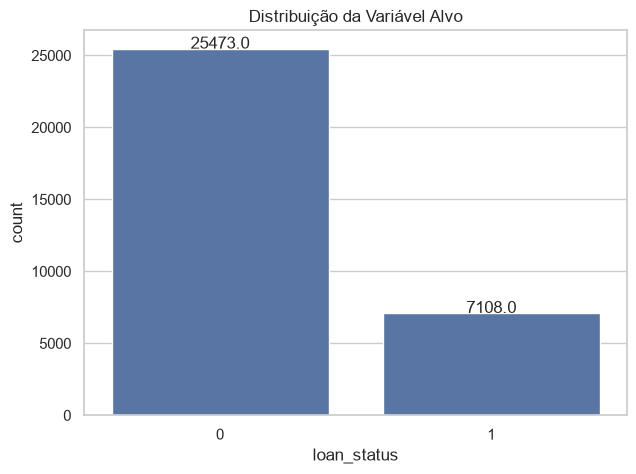

In [3991]:
plt.figure(figsize=(7,5))

ax = sns.countplot(

data=df,

x="loan_status"

)

for barra in ax.patches:

    altura = barra.get_height()

    ax.text(

        barra.get_x()+barra.get_width()/2,

        altura,

        f"{altura}",

        ha="center"

    )

plt.title("Distribuição da Variável Alvo")

plt.show()

### Análise da Variável Alvo

Observa-se que a variável `loan_status` apresenta distribuição desbalanceada entre as classes.

A maior parte dos registros corresponde a clientes adimplentes (`loan_status = 0`), enquanto a classe dos clientes inadimplentes (`loan_status = 1`) representa uma parcela significativamente menor da base.

Esse comportamento poderá influenciar negativamente o treinamento dos algoritmos, levando o modelo a favorecer a classe majoritária.

Para evitar esse problema, será aplicada posteriormente uma técnica de balanceamento de classes (SMOTE), exclusivamente sobre os dados de treinamento, evitando Data Leakage.

## 2.5 Análise Visual das Distribuições

Após a análise estatística descritiva, será realizada uma análise gráfica das variáveis numéricas utilizando histogramas.

O objetivo é compreender o comportamento das distribuições, identificar possíveis assimetrias e levantar evidências para orientar o tratamento dos dados nas próximas etapas do pipeline.

### Funções Auxiliares para Visualização

In [3992]:
def plotar_histograma(dataframe, coluna, bins=30):
    """
    Plota o histograma de uma variável numérica.

    Parâmetros:
    dataframe : DataFrame contendo os dados.
    coluna : Nome da variável.
    bins : Quantidade de intervalos do histograma.
    """

    plt.figure(figsize=(8,5))

    plt.hist(
        dataframe[coluna].dropna(),
        bins=bins,
        edgecolor="black"
    )

    plt.title(f"Distribuição de {coluna}", fontsize=14)

    plt.xlabel(coluna)

    plt.ylabel("Frequência")

    plt.grid(axis="y", alpha=0.3)

    plt.show()

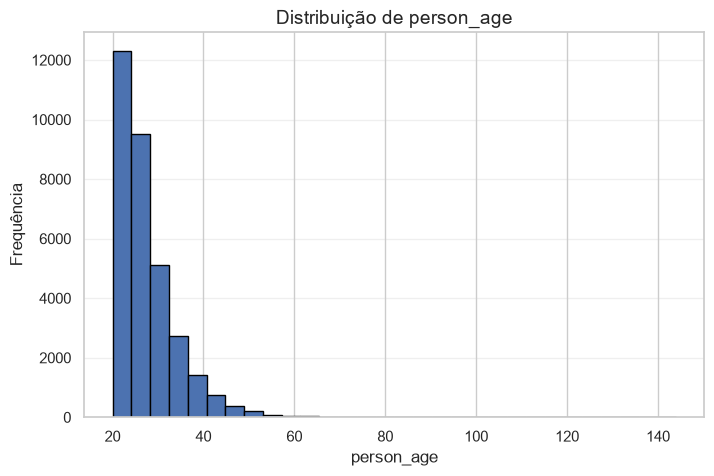

In [3993]:
plotar_histograma(df, "person_age")

### Análise da variável `person_age`

A distribuição das idades apresenta forte concentração entre aproximadamente 20 e 35 anos, indicando que a maior parte dos clientes pertence à população adulta jovem.

Observa-se uma cauda à direita, com poucos registros em idades mais elevadas, caracterizando uma distribuição assimétrica positiva.

Também foram identificados valores muito superiores à maioria da população, sugerindo possíveis outliers ou inconsistências cadastrais. Esses registros serão investigados posteriormente por meio de boxplots e do método do Intervalo Interquartil (IQR).

Nesta etapa, nenhum registro foi removido ou alterado.

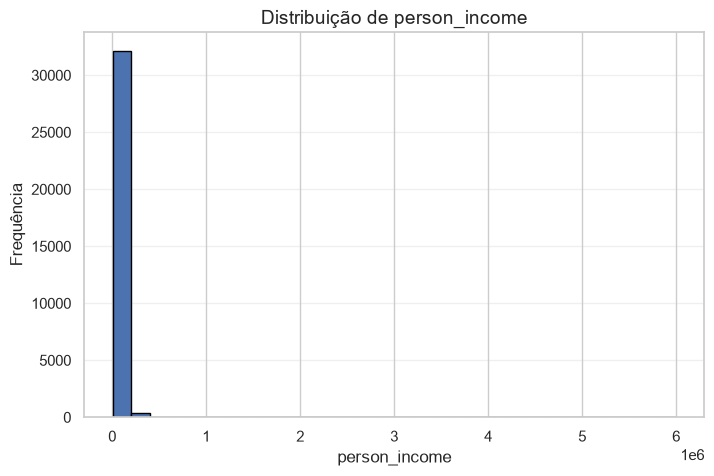

In [3994]:
plotar_histograma(df, "person_income")

Para facilitar a interpretação da concentração principal dos dados, o histograma foi limitado visualmente ao percentil 99. Nenhum registro foi removido da base nesta etapa.

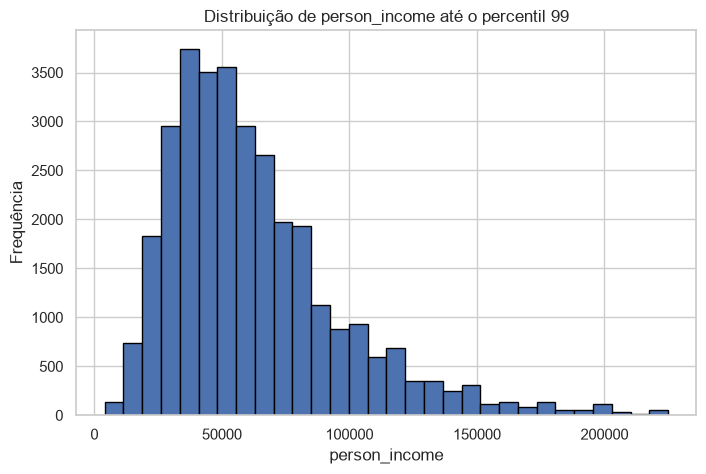

In [3995]:
limite_visual = df["person_income"].quantile(0.99)

plt.figure(figsize=(8, 5))

plt.hist(
    df.loc[df["person_income"] <= limite_visual, "person_income"].dropna(),
    bins=30,
    edgecolor="black"
)

plt.title("Distribuição de person_income até o percentil 99")
plt.xlabel("person_income")
plt.ylabel("Frequência")
plt.show()

### Análise da variável `person_income`

Para facilitar a interpretação da distribuição principal, o histograma foi limitado ao percentil 99 apenas para fins de visualização, sem qualquer alteração na base de dados.

Observa-se concentração da maior parte das rendas entre aproximadamente 25 mil e 80 mil, acompanhada por uma cauda extensa à direita.

Esse comportamento caracteriza forte assimetria positiva, indicando a presença de poucos clientes com rendas significativamente superiores à maioria.

Caso seja necessário realizar imputação de valores ausentes, a mediana tende a representar melhor a distribuição do que a média, por ser menos influenciada por valores extremos.

Os possíveis outliers serão avaliados posteriormente utilizando boxplots e o método IQR.

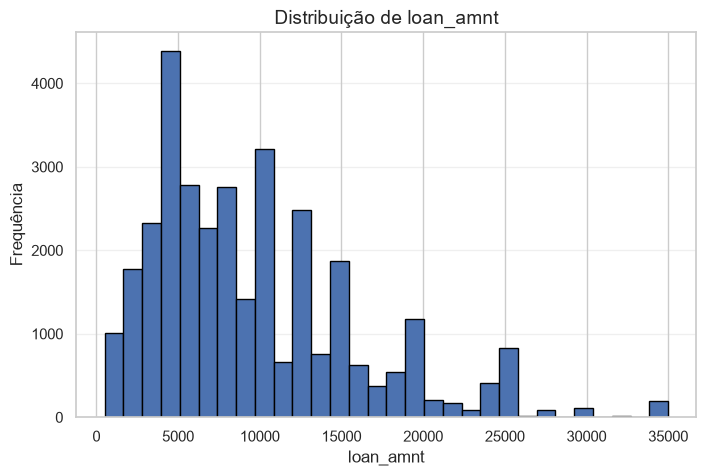

In [3996]:
plotar_histograma(df, "loan_amnt")

### Análise da variável `loan_amnt`

Os valores de empréstimo apresentam maior concentração entre aproximadamente 3 mil e 15 mil, indicando que a instituição financeira concede predominantemente operações de pequeno e médio porte.

A distribuição apresenta uma cauda à direita, evidenciando a existência de empréstimos de maior valor, porém em quantidade significativamente menor.

Também foram observadas concentrações em faixas específicas de valores, sugerindo que o banco pode adotar limites padronizados para concessão de crédito.

Os valores mais elevados serão investigados posteriormente por meio de boxplots e do método IQR para verificar se representam operações legítimas ou possíveis valores extremos.

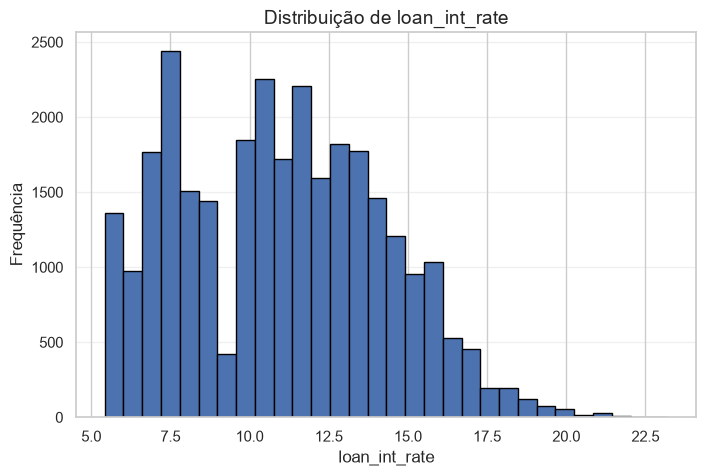

In [3997]:
plotar_histograma(df, "loan_int_rate")

### Análise da variável `loan_int_rate`

A distribuição das taxas de juros apresenta maior concentração entre aproximadamente 7% e 15%.

Observa-se uma cauda à direita, indicando que alguns empréstimos possuem taxas superiores à média da população.

Embora existam registros próximos de 20% a 23%, esses valores podem representar operações de crédito destinadas a clientes com maior risco e, portanto, não devem ser considerados automaticamente como inconsistências.

A confirmação da presença de outliers será realizada posteriormente por meio dos boxplots e do método IQR.

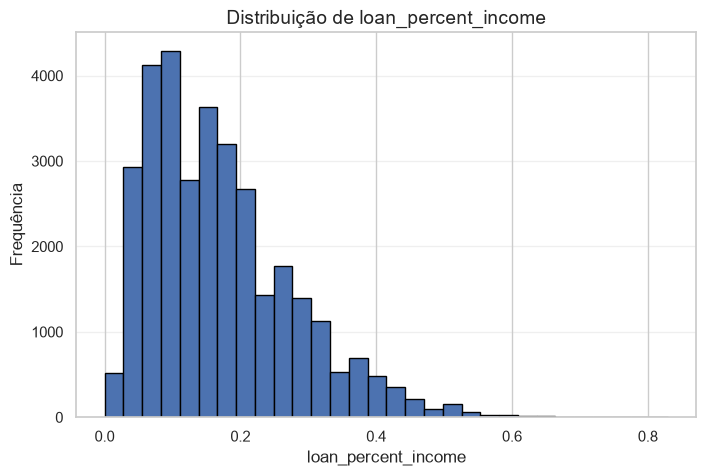

In [3998]:
plotar_histograma(df, "loan_percent_income")

### Análise da variável `loan_percent_income`

A maior parte dos clientes compromete entre aproximadamente 5% e 25% da renda com o pagamento do empréstimo.

A distribuição apresenta uma cauda à direita, indicando que alguns clientes possuem um comprometimento significativamente superior ao restante da população.

Esses valores elevados não devem ser tratados automaticamente como inconsistências, pois podem representar justamente clientes com maior probabilidade de inadimplência.

Essa característica torna a variável potencialmente importante para os modelos de classificação.

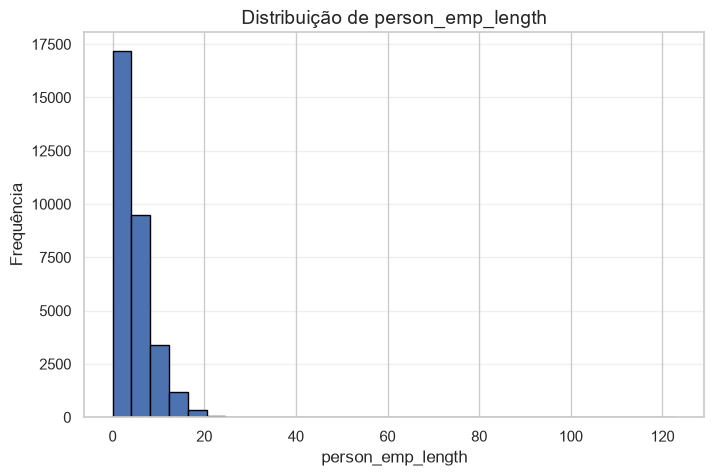

In [3999]:
plotar_histograma(df, "person_emp_length")

### Análise da variável `person_emp_length`

Observa-se que a maior parte dos clientes possui entre 0 e 10 anos de experiência profissional.

A distribuição apresenta forte assimetria positiva, acompanhada por poucos registros extremamente elevados.

Alguns valores observados ultrapassam limites plausíveis para tempo de experiência profissional, sugerindo possíveis inconsistências cadastrais.

Esses registros serão avaliados posteriormente utilizando boxplots e o método IQR antes da definição da estratégia de tratamento.

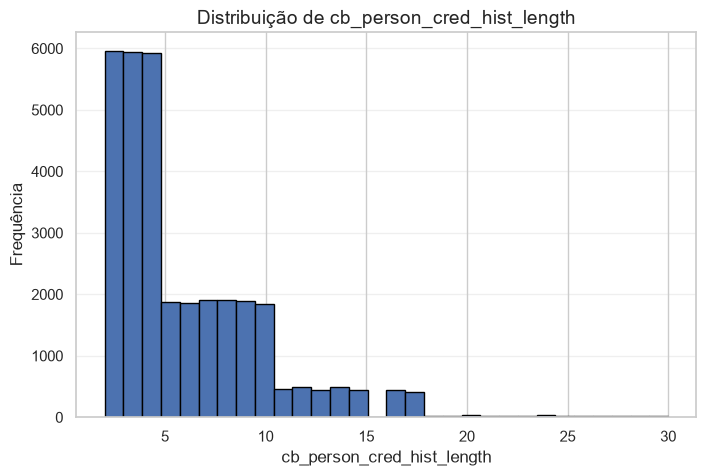

In [4000]:
plotar_histograma(df, "cb_person_cred_hist_length")

### Análise da variável `cb_person_cred_hist_length`

A maior parte dos clientes apresenta histórico de crédito entre aproximadamente 2 e 10 anos.

A distribuição apresenta uma cauda à direita, indicando que alguns clientes possuem relacionamento bancário significativamente mais longo.

Embora existam poucos registros superiores a 20 anos, esses valores são compatíveis com clientes de maior idade e não representam, neste momento, indícios claros de inconsistências.

A confirmação da presença de valores extremos será realizada posteriormente utilizando boxplots e o método IQR.

### Tabela de hipóteses das distribuições

A tabela a seguir combina medidas estatísticas calculadas automaticamente com interpretações obtidas a partir dos histogramas.

As hipóteses ainda são provisórias e serão confirmadas ou refutadas nas próximas etapas por meio de boxplots e do método do Intervalo Interquartil (IQR).

In [4001]:
variaveis_analisadas = [
    "person_age",
    "person_income",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "person_emp_length",
    "cb_person_cred_hist_length"
]


def classificar_assimetria(valor):
    valor_absoluto = abs(valor)

    if valor_absoluto < 0.5:
        return "Baixa"
    elif valor_absoluto < 1:
        return "Moderada"
    else:
        return "Elevada"


analise_distribuicoes = pd.DataFrame({
    "Variável": variaveis_analisadas,

    "Média": [
        df[coluna].mean()
        for coluna in variaveis_analisadas
    ],

    "Mediana": [
        df[coluna].median()
        for coluna in variaveis_analisadas
    ],

    "Assimetria calculada": [
        df[coluna].skew()
        for coluna in variaveis_analisadas
    ],

    "Mínimo": [
        df[coluna].min()
        for coluna in variaveis_analisadas
    ],

    "Máximo": [
        df[coluna].max()
        for coluna in variaveis_analisadas
    ],

    "Distribuição observada": [
        "Concentrada entre 20 e 35 anos",
        "Concentrada entre 25 mil e 80 mil",
        "Concentrada entre 3 mil e 15 mil",
        "Concentrada entre 7% e 15%",
        "Concentrada entre 5% e 25% da renda",
        "Concentrada entre 0 e 10 anos",
        "Concentrada entre 2 e 10 anos"
    ],

    "Evidências observadas": [
        "Cauda à direita e idades muito superiores à concentração principal",
        "Cauda longa e valores máximos extremamente elevados",
        "Cauda à direita e picos em valores padronizados",
        "Cauda à direita e poucas taxas superiores a 20%",
        "Cauda à direita e poucos clientes com alto comprometimento",
        "Cauda longa e valores acima dos limites plausíveis",
        "Cauda à direita, porém valores altos ainda plausíveis"
    ],

    "Hipótese inicial": [
        "Investigar possíveis inconsistências cadastrais",
        "Usar mediana para imputação e investigar outliers",
        "Confirmar outliers com boxplot e IQR",
        "Usar mediana para imputação e confirmar possíveis outliers",
        "Manter valores altos até avaliar relação com inadimplência",
        "Usar mediana e tratar valores inconsistentes",
        "Manter valores e confirmar comportamento com boxplot"
    ]
})


analise_distribuicoes["Classificação automática"] = (
    analise_distribuicoes["Assimetria calculada"]
    .apply(classificar_assimetria)
)


analise_distribuicoes = analise_distribuicoes[
    [
        "Variável",
        "Média",
        "Mediana",
        "Assimetria calculada",
        "Classificação automática",
        "Mínimo",
        "Máximo",
        "Distribuição observada",
        "Evidências observadas",
        "Hipótese inicial"
    ]
]


display(
    analise_distribuicoes.round(2)
)

,Variável,Média,Mediana,Assimetria calculada,Classificação automática,Mínimo,Máximo,Distribuição observada,Evidências observadas,Hipótese inicial
0,person_age,27.73,26.00,2.58,Elevada,20.00,144.00,Concentrada entre 20 e 35 anos,Cauda à direita e idades muito superiores à co...,Investigar possíveis inconsistências cadastrais
1,person_income,66074.85,55000.00,32.87,Elevada,4000.00,6000000.00,Concentrada entre 25 mil e 80 mil,Cauda longa e valores máximos extremamente ele...,Usar mediana para imputação e investigar outliers
2,loan_amnt,9589.37,8000.00,1.19,Elevada,500.00,35000.00,Concentrada entre 3 mil e 15 mil,Cauda à direita e picos em valores padronizados,Confirmar outliers com boxplot e IQR
3,loan_int_rate,11.01,10.99,0.21,Baixa,5.42,23.22,Concentrada entre 7% e 15%,Cauda à direita e poucas taxas superiores a 20%,Usar mediana para imputação e confirmar possív...
4,loan_percent_income,0.17,0.15,1.06,Elevada,0.00,0.83,Concentrada entre 5% e 25% da renda,Cauda à direita e poucos clientes com alto com...,Manter valores altos até avaliar relação com i...
5,person_emp_length,4.79,4.00,2.61,Elevada,0.00,123.00,Concentrada entre 0 e 10 anos,Cauda longa e valores acima dos limites plausí...,Usar mediana e tratar valores inconsistentes
6,cb_person_cred_hist_length,5.80,4.00,1.66,Elevada,2.00,30.00,Concentrada entre 2 e 10 anos,"Cauda à direita, porém valores altos ainda pla...",Manter valores e confirmar comportamento com b...


## 2.6 Análise Visual de Outliers

Após a análise das distribuições, serão utilizados boxplots para identificar valores extremos nas variáveis numéricas.

O objetivo é verificar quais observações se encontram fora do comportamento predominante da base e avaliar se representam erros, casos legítimos ou informações importantes para o problema de negócio.

Nenhum valor será removido nesta etapa.

### Função Auxiliar para Boxplots

In [4002]:
def plotar_boxplot(dataframe, coluna):
    """
    Plota um boxplot horizontal para uma variável numérica.

    Parâmetros:
    dataframe: DataFrame contendo os dados.
    coluna: nome da variável numérica.
    """

    plt.figure(figsize=(9, 4))

    sns.boxplot(
        x=dataframe[coluna]
    )

    plt.title(f"Boxplot de {coluna}")
    plt.xlabel(coluna)

    plt.show()

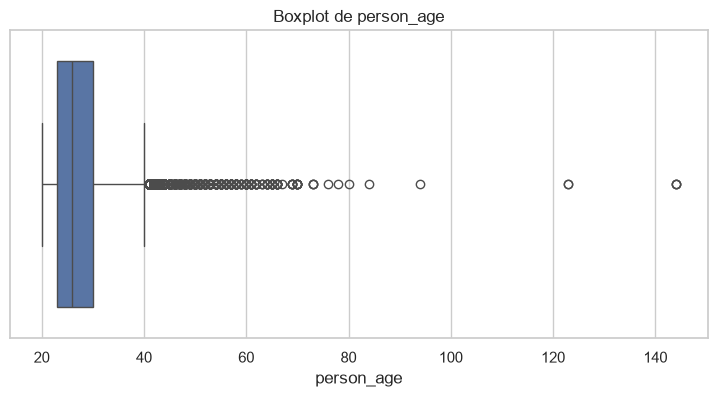

In [4003]:
plotar_boxplot(df, "person_age")

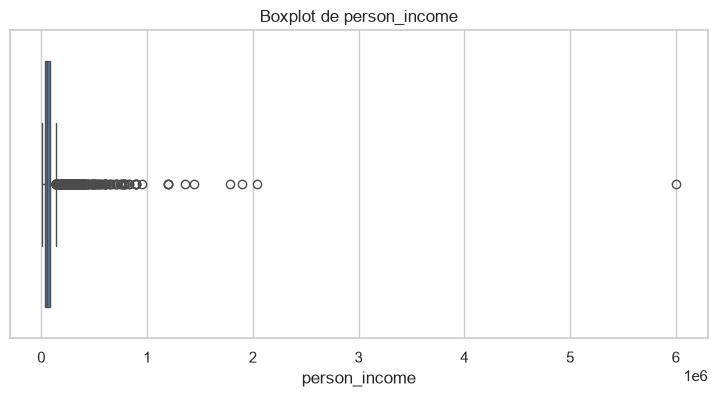

In [4004]:
plotar_boxplot(df, "person_income")

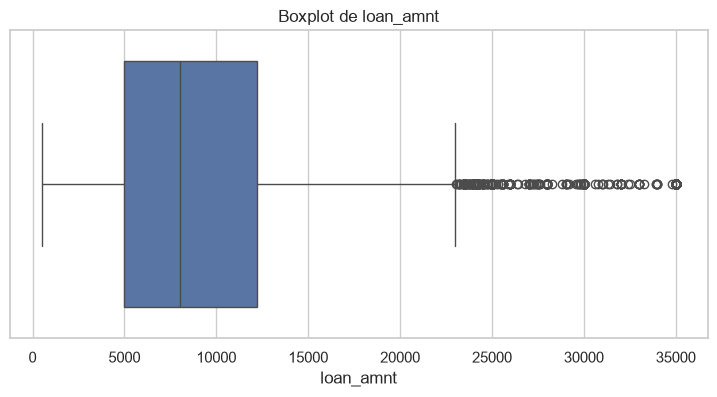

In [4005]:
plotar_boxplot(df, "loan_amnt")

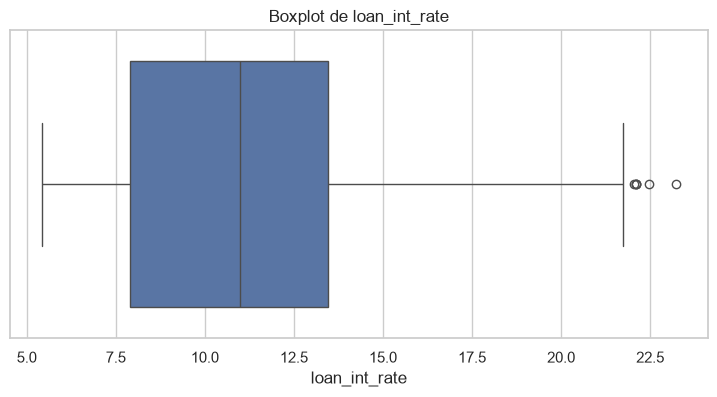

In [4006]:
plotar_boxplot(df, "loan_int_rate")

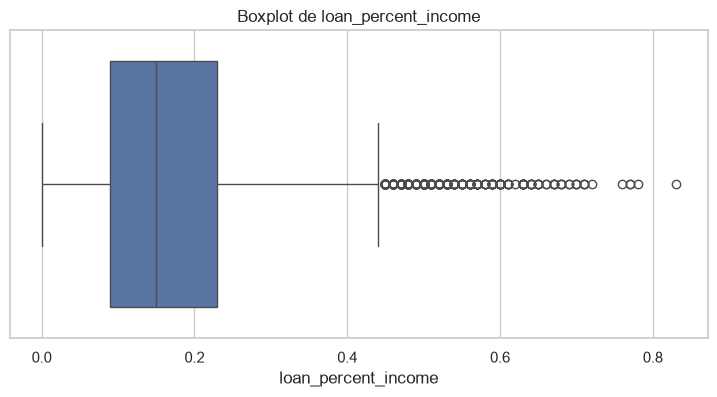

In [4007]:
plotar_boxplot(df, "loan_percent_income")

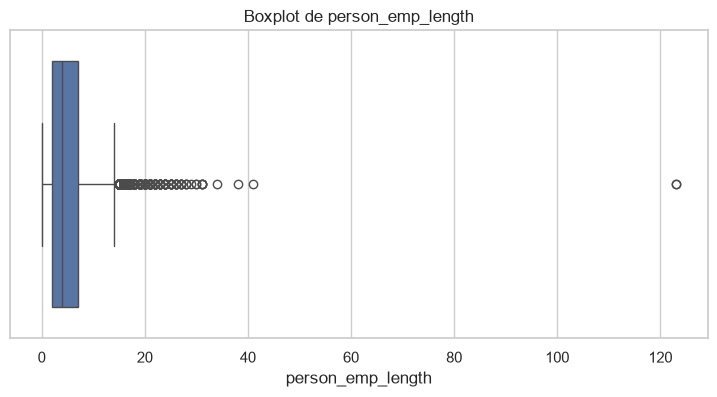

In [4008]:
plotar_boxplot(df, "person_emp_length")

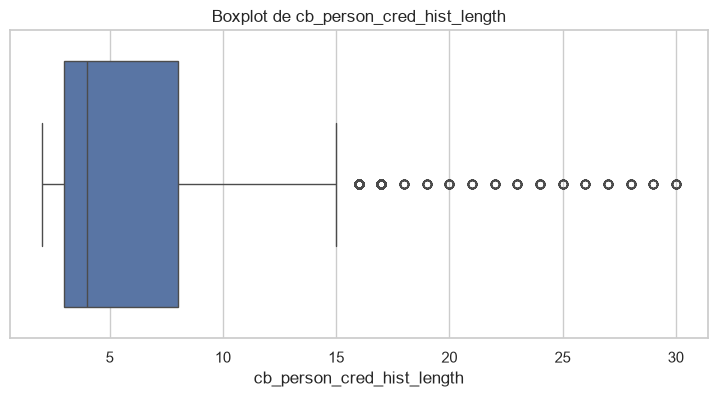

In [4009]:
plotar_boxplot(df, "cb_person_cred_hist_length")

função para calcular os limites estatísticos:

In [4010]:
def calcular_limites_iqr(dataframe, coluna):
    """
    Calcula os limites inferior e superior pelo método IQR.
    """

    q1 = dataframe[coluna].quantile(0.25)
    q3 = dataframe[coluna].quantile(0.75)

    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    return q1, q3, iqr, limite_inferior, limite_superior

testando com uma variavel

In [4011]:
q1, q3, iqr, limite_inferior, limite_superior = calcular_limites_iqr(
    df,
    "person_income"
)

print(f"Q1: {q1:.2f}")
print(f"Q3: {q3:.2f}")
print(f"IQR: {iqr:.2f}")
print(f"Limite inferior: {limite_inferior:.2f}")
print(f"Limite superior: {limite_superior:.2f}")

Q1: 38500.00
Q3: 79200.00
IQR: 40700.00
Limite inferior: -22550.00
Limite superior: 140250.00


função para contar os possíveis outiers

In [4012]:
def contar_outliers_iqr(dataframe, coluna):
    """
    Conta valores abaixo e acima dos limites do IQR.
    """

    q1, q3, iqr, limite_inferior, limite_superior = calcular_limites_iqr(
        dataframe,
        coluna
    )

    outliers_inferiores = dataframe[
        dataframe[coluna] < limite_inferior
    ].shape[0]

    outliers_superiores = dataframe[
        dataframe[coluna] > limite_superior
    ].shape[0]

    total_outliers = outliers_inferiores + outliers_superiores

    return {
        "Variável": coluna,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Limite inferior": limite_inferior,
        "Limite superior": limite_superior,
        "Outliers inferiores": outliers_inferiores,
        "Outliers superiores": outliers_superiores,
        "Total de outliers": total_outliers
    }

tabela consolidada de outliers

In [4013]:
variaveis_outliers = [
    "person_age",
    "person_income",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "person_emp_length",
    "cb_person_cred_hist_length"
]

resultados_outliers = [
    contar_outliers_iqr(df, coluna)
    for coluna in variaveis_outliers
]

tabela_outliers = pd.DataFrame(resultados_outliers)

display(
    tabela_outliers.round(2)
)

,Variável,Q1,Q3,IQR,Limite inferior,Limite superior,Outliers inferiores,Outliers superiores,Total de outliers
0,person_age,23.00,30.00,7.00,12.50,40.50,0,1494,1494
1,person_income,38500.00,79200.00,40700.00,-22550.00,140250.00,0,1484,1484
2,loan_amnt,5000.00,12200.00,7200.00,-5800.00,23000.00,0,1689,1689
3,loan_int_rate,7.90,13.47,5.57,-0.46,21.83,0,6,6
4,loan_percent_income,0.09,0.23,0.14,-0.12,0.44,0,651,651
5,person_emp_length,2.00,7.00,5.00,-5.50,14.50,0,853,853
6,cb_person_cred_hist_length,3.00,8.00,5.00,-4.50,15.50,0,1142,1142


In [4014]:
tabela_outliers["Percentual de outliers"] = (
    tabela_outliers["Total de outliers"] / len(df) * 100
).round(2)

display(
    tabela_outliers.round(2)
)

,Variável,Q1,Q3,IQR,Limite inferior,Limite superior,Outliers inferiores,Outliers superiores,Total de outliers,Percentual de outliers
0,person_age,23.00,30.00,7.00,12.50,40.50,0,1494,1494,4.59
1,person_income,38500.00,79200.00,40700.00,-22550.00,140250.00,0,1484,1484,4.55
2,loan_amnt,5000.00,12200.00,7200.00,-5800.00,23000.00,0,1689,1689,5.18
3,loan_int_rate,7.90,13.47,5.57,-0.46,21.83,0,6,6,0.02
4,loan_percent_income,0.09,0.23,0.14,-0.12,0.44,0,651,651,2.00
5,person_emp_length,2.00,7.00,5.00,-5.50,14.50,0,853,853,2.62
6,cb_person_cred_hist_length,3.00,8.00,5.00,-4.50,15.50,0,1142,1142,3.51


In [4015]:
decisoes_outliers = pd.DataFrame({
    "Variável": [
        "person_age",
        "person_income",
        "loan_amnt",
        "loan_int_rate",
        "loan_percent_income",
        "person_emp_length",
        "cb_person_cred_hist_length"
    ],

    "Diagnóstico provisório": [
        "Possíveis idades inconsistentes",
        "Valores extremos possivelmente legítimos",
        "Valores altos possivelmente legítimos",
        "Taxas altas plausíveis conforme risco",
        "Valores extremos potencialmente relevantes para inadimplência",
        "Fortes indícios de inconsistência cadastral",
        "Valores elevados plausíveis"
    ],

    "Estratégia provisória": [
        "Investigar registros acima de limite plausível",
        "Manter por enquanto",
        "Manter por enquanto",
        "Manter por enquanto",
        "Manter por relevância preditiva",
        "Investigar e tratar valores impossíveis",
        "Manter"
    ]
})

display(decisoes_outliers)

,Variável,Diagnóstico provisório,Estratégia provisória
0,person_age,Possíveis idades inconsistentes,Investigar registros acima de limite plausível
1,person_income,Valores extremos possivelmente legítimos,Manter por enquanto
2,loan_amnt,Valores altos possivelmente legítimos,Manter por enquanto
3,loan_int_rate,Taxas altas plausíveis conforme risco,Manter por enquanto
4,loan_percent_income,Valores extremos potencialmente relevantes par...,Manter por relevância preditiva
5,person_emp_length,Fortes indícios de inconsistência cadastral,Investigar e tratar valores impossíveis
6,cb_person_cred_hist_length,Valores elevados plausíveis,Manter


### Decisão do Cientista de Dados — Outliers

A análise por boxplots e pelo método IQR identificou valores estatisticamente extremos em diversas variáveis.

Entretanto, nem todo valor extremo representa erro. Variáveis financeiras, como renda, valor do empréstimo e taxa de juros, podem conter valores elevados legítimos e relevantes para o problema de negócio.

As variáveis `person_age` e `person_emp_length` exigem maior atenção, pois valores muito elevados podem representar inconsistências cadastrais.

A variável `loan_percent_income` também apresentou valores extremos, mas esses registros podem ser importantes para identificar clientes com maior risco de inadimplência.

Nenhum outlier será removido automaticamente. A decisão final será baseada na plausibilidade dos valores, no impacto sobre o KNN e na preservação de informações relevantes para a Árvore de Decisão.

### Impacto dos Outliers nos Modelos

O KNN utiliza distâncias entre observações e, por isso, é sensível a valores extremos. Outliers podem alterar significativamente a noção de proximidade entre os clientes.

A Árvore de Decisão é mais robusta a outliers, pois realiza divisões baseadas em limites e regras condicionais.

Por esse motivo, o tratamento de valores extremos será realizado com cautela, evitando a remoção de informações legítimas e relevantes para o risco de crédito.

## 2.7 Correlação entre Variáveis

Nesta etapa será analisada a correlação linear entre as variáveis numéricas por meio do coeficiente de Pearson.

O objetivo é identificar relações lineares relevantes entre os atributos e verificar possíveis indícios de redundância de informações.

selecionando variáveis numericas

In [4016]:
variaveis_numericas = df.select_dtypes(include="number")

calculando matriz

In [4017]:
matriz_correlacao = variaveis_numericas.corr(
    method="pearson"
)

matriz_correlacao

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
person_age,1.000000,0.173202,0.163106,0.050787,0.012580,-0.021629,-0.042411,0.859133
person_income,0.173202,1.000000,0.134268,0.266820,0.000792,-0.144449,-0.254471,0.117987
person_emp_length,0.163106,0.134268,1.000000,0.113082,-0.056405,-0.082489,-0.054111,0.144699
loan_amnt,0.050787,0.266820,0.113082,1.000000,0.146813,0.105376,0.572612,0.041967
loan_int_rate,0.012580,0.000792,-0.056405,0.146813,1.000000,0.335133,0.120314,0.016696
loan_status,-0.021629,-0.144449,-0.082489,0.105376,0.335133,1.000000,0.379366,-0.015529
loan_percent_income,-0.042411,-0.254471,-0.054111,0.572612,0.120314,0.379366,1.000000,-0.031690
cb_person_cred_hist_length,0.859133,0.117987,0.144699,0.041967,0.016696,-0.015529,-0.031690,1.000000


heatmap

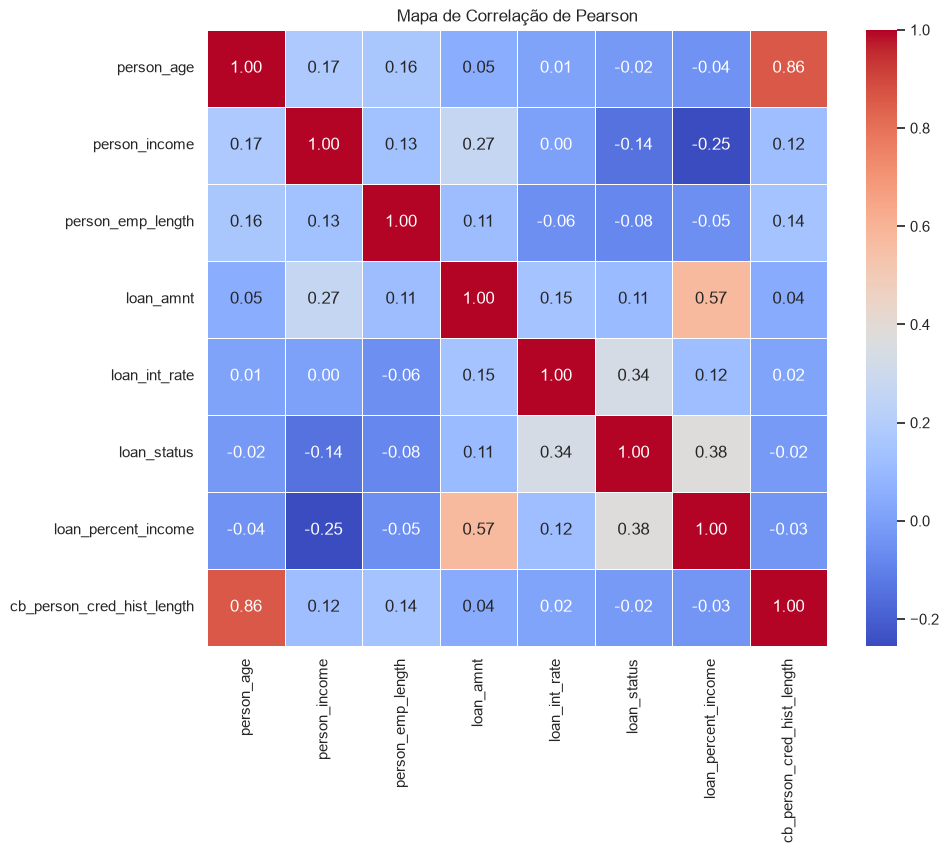

In [4018]:
plt.figure(figsize=(10,8))

sns.heatmap(
    matriz_correlacao,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Mapa de Correlação de Pearson")

plt.show()

criando uma tabela

In [4019]:
# Cria uma máscara para manter apenas a parte superior da matriz,
# removendo a diagonal principal e as correlações duplicadas.
mascara_superior = np.triu(
    np.ones(matriz_correlacao.shape),
    k=1
).astype(bool)

# Converte os pares de correlação em uma tabela.
tabela_correlacao = (
    matriz_correlacao
    .where(mascara_superior)
    .stack()
    .reset_index()
)

# Renomeia as colunas.
tabela_correlacao.columns = [
    "Variável 1",
    "Variável 2",
    "Correlação"
]

# Remove correlações ausentes e ordena da maior para a menor.
tabela_correlacao = (
    tabela_correlacao
    .dropna(subset=["Correlação"])
    .sort_values(
        by="Correlação",
        ascending=False
    )
    .reset_index(drop=True)
)

display(tabela_correlacao.round(3))

,Variável 1,Variável 2,Correlação
0,person_age,cb_person_cred_hist_length,0.859
1,loan_amnt,loan_percent_income,0.573
2,loan_status,loan_percent_income,0.379
3,loan_int_rate,loan_status,0.335
4,person_income,loan_amnt,0.267
5,person_age,person_income,0.173
6,person_age,person_emp_length,0.163
7,loan_amnt,loan_int_rate,0.147
8,person_emp_length,cb_person_cred_hist_length,0.145
9,person_income,person_emp_length,0.134


### Tabela de correlações únicas

A matriz de correlação é simétrica, o que significa que a correlação entre duas variáveis aparece duas vezes.

Para evitar duplicidade, foi utilizada apenas a parte superior da matriz, excluindo a diagonal principal.

Os valores ausentes gerados pela máscara triangular foram removidos explicitamente antes da ordenação das correlações.

### Análise da Correlação

O mapa de calor de Pearson permitiu identificar a intensidade das relações lineares entre as variáveis numéricas do conjunto de dados.

A correlação positiva mais elevada foi observada entre `person_age` e `cb_person_cred_hist_length` (0,86), indicando que clientes mais velhos tendem a possuir um histórico de crédito mais longo. Esse comportamento é coerente com o contexto financeiro e não representa uma inconsistência dos dados.

Também foi identificada uma correlação positiva moderada entre `loan_amnt` e `loan_percent_income` (0,57), sugerindo que empréstimos de maior valor tendem a comprometer uma parcela maior da renda do cliente.

Em relação à variável alvo (`loan_status`), as maiores correlações ocorreram com `loan_percent_income` (0,38) e `loan_int_rate` (0,34). Embora essas correlações sejam moderadas, elas indicam que essas variáveis possuem potencial preditivo para identificar clientes com maior probabilidade de inadimplência.

As demais variáveis apresentaram correlações fracas, indicando baixa redundância de informações entre os atributos utilizados pelos modelos de Machine Learning.

### Decisão do Cientista de Dados

A análise de correlação não identificou evidências de multicolinearidade severa entre as variáveis explicativas que justificassem sua remoção nesta etapa.

As correlações observadas são compatíveis com o comportamento esperado para operações de crédito e fornecem informações potencialmente relevantes para os modelos de classificação.

Portanto, todas as variáveis numéricas serão mantidas para as próximas etapas do pipeline, sendo posteriormente avaliadas durante o treinamento dos modelos KNN e Árvore de Decisão.

# 3. Tratamento e Limpeza dos Dados

Após a conclusão da Análise Exploratória, será iniciada a preparação da base.

Nesta etapa serão realizadas as correções necessárias para garantir a qualidade dos dados antes da divisão entre treino e teste.

As decisões serão baseadas nas evidências obtidas durante a EDA, evitando alterações automáticas ou sem justificativa estatística.

preservando base original:

In [4020]:
df_tratado = df.copy()

## 3.1 Criação da Base de Trabalho

Foi criada uma cópia do DataFrame original para realizar as etapas de tratamento.

Essa abordagem preserva a base bruta carregada inicialmente e permite comparar os dados antes e depois das transformações.

In [4021]:
linhas_antes, colunas_antes = df_tratado.shape

print(f"Linhas antes do tratamento: {linhas_antes}")
print(f"Colunas antes do tratamento: {colunas_antes}")

Linhas antes do tratamento: 32581
Colunas antes do tratamento: 12


## 3.2 Tratamento de Registros Duplicados

Registros completamente duplicados podem aumentar artificialmente a frequência de determinados perfis e introduzir viés durante o treinamento dos modelos.

Por esse motivo, as linhas totalmente duplicadas serão removidas da base de trabalho.

In [4022]:
quantidade_duplicados = df_tratado.duplicated().sum()

print(f"Quantidade de registros duplicados: {quantidade_duplicados}")

Quantidade de registros duplicados: 165


In [4023]:
df_tratado = df_tratado.drop_duplicates().copy()
#Após operações de filtragem, .copy() cria um DataFrame independente e ajuda a evitar avisos ou alterações ambíguas no pandas.

In [4024]:
duplicados_restantes = df_tratado.duplicated().sum()

print(f"Duplicados após o tratamento: {duplicados_restantes}")
print(f"Novo tamanho da base: {df_tratado.shape}")

Duplicados após o tratamento: 0
Novo tamanho da base: (32416, 12)


In [4025]:
linhas_depois_duplicados = len(df_tratado)

duplicados_removidos = (
    linhas_antes - linhas_depois_duplicados
)

print(f"Registros removidos: {duplicados_removidos}")

Registros removidos: 165


### Decisão do Cientista de Dados — Duplicatas

As linhas completamente duplicadas foram removidas porque não adicionam novas informações ao conjunto de dados e poderiam aumentar artificialmente a importância de determinados perfis.

A remoção foi aplicada somente à cópia de trabalho, mantendo a base original preservada.

validando valores ausentes

In [4026]:
nulos_antes_tratamento = pd.DataFrame({
    "quantidade": df_tratado.isna().sum(),
    "percentual": (
        df_tratado.isna().mean() * 100
    ).round(2)
})

nulos_antes_tratamento = nulos_antes_tratamento[
    nulos_antes_tratamento["quantidade"] > 0
]

nulos_antes_tratamento

,quantidade,percentual
person_emp_length,887,2.74
loan_int_rate,3095,9.55


## Tratamento dos dados

A base original foi preservada e uma cópia de trabalho foi criada para a aplicação das etapas de limpeza.

Os registros completamente duplicados foram removidos para evitar redundância e possível viés estatístico.

## 3.3 Tratamento de Valores Ausentes

Após a análise exploratória, os valores ausentes serão tratados com base no comportamento estatístico de cada variável.

A escolha entre média e mediana será fundamentada na distribuição dos dados e na presença de assimetria e valores extremos.

confirmando nulos

In [4027]:
nulos_df_tratado = pd.DataFrame({
    "quantidade": df_tratado.isna().sum(),
    "percentual": (df_tratado.isna().mean() * 100).round(2)
})

nulos_df_tratado = nulos_df_tratado[
    nulos_df_tratado["quantidade"] > 0
]

nulos_df_tratado

,quantidade,percentual
person_emp_length,887,2.74
loan_int_rate,3095,9.55


comparando media e mediana

In [4028]:
colunas_com_nulos = nulos_df_tratado.index.tolist()

comparacao_imputacao = pd.DataFrame({
    "media": df_tratado[colunas_com_nulos].mean(),
    "mediana": df_tratado[colunas_com_nulos].median(),
    "assimetria": df_tratado[colunas_com_nulos].skew()
})

comparacao_imputacao.round(2)

,media,mediana,assimetria
person_emp_length,4.79,4.00,2.62
loan_int_rate,11.02,10.99,0.21


### Decisão do Cientista de Dados — Imputação

A variável `person_emp_length` apresentou forte assimetria positiva e valores extremos incompatíveis com o comportamento da maioria dos registros. Por esse motivo, a mediana foi escolhida como técnica de imputação, pois é menos sensível a valores extremos.

A variável `loan_int_rate` apresentou assimetria positiva moderada e alguns valores elevados. A mediana também foi escolhida para preservar uma medida central mais robusta.

A média não foi utilizada porque poderia ser deslocada pelos valores extremos observados durante a EDA.

calculando medianas

In [4029]:
mediana_emprego = df_tratado["person_emp_length"].median()
mediana_juros = df_tratado["loan_int_rate"].median()

print(f"Mediana de person_emp_length: {mediana_emprego:.2f}")
print(f"Mediana de loan_int_rate: {mediana_juros:.2f}")

Mediana de person_emp_length: 4.00
Mediana de loan_int_rate: 10.99


imputando

In [4030]:
df_tratado["person_emp_length"] = (
    df_tratado["person_emp_length"]
    .fillna(mediana_emprego)
)

df_tratado["loan_int_rate"] = (
    df_tratado["loan_int_rate"]
    .fillna(mediana_juros)
)

validando tratamento

In [4031]:
nulos_apos_imputacao = df_tratado[
    ["person_emp_length", "loan_int_rate"]
].isna().sum()

nulos_apos_imputacao

person_emp_length    0
loan_int_rate        0
dtype: int64

validando a base inteira

In [4032]:
print(
    f"Total de valores nulos após imputação: "
    f"{df_tratado.isna().sum().sum()}"
)

Total de valores nulos após imputação: 0


comparando antes e depois

In [4033]:
resumo_imputacao = pd.DataFrame({
    "variavel": [
        "person_emp_length",
        "loan_int_rate"
    ],
    "metodo": [
        "Mediana",
        "Mediana"
    ],
    "valor_utilizado": [
        mediana_emprego,
        mediana_juros
    ],
    "nulos_restantes": [
        df_tratado["person_emp_length"].isna().sum(),
        df_tratado["loan_int_rate"].isna().sum()
    ]
})

resumo_imputacao.round(2)

,variavel,metodo,valor_utilizado,nulos_restantes
0,person_emp_length,Mediana,4.00,0
1,loan_int_rate,Mediana,10.99,0


### Resultado do Tratamento de Valores Ausentes

Os valores ausentes das variáveis `person_emp_length` e `loan_int_rate` foram preenchidos com suas respectivas medianas.

Após a imputação, não restaram valores ausentes nessas colunas.

A técnica foi escolhida por ser mais robusta diante das assimetrias e dos valores extremos identificados durante a análise exploratória.

## 3.4 Tratamento de Inconsistências Cadastrais

A análise exploratória identificou valores extremos nas variáveis `person_age` e `person_emp_length`.

Nesta etapa serão aplicadas regras de plausibilidade para diferenciar valores extremos legítimos de possíveis erros cadastrais.

As decisões serão baseadas em coerência lógica e conhecimento de negócio.

verificando idade pessoa

In [4034]:
df_tratado["person_age"].sort_values(
    ascending=False
).head(20)

32297    144
81       144
183      144
747      123
575      123
32416     94
32506     84
32422     80
32355     78
32534     76
32521     73
32432     73
32381     73
32385     70
32334     70
32383     70
32360     70
32532     70
32522     70
32436     70
Name: person_age, dtype: int64

In [4035]:
df_tratado[
    df_tratado["person_age"] > 100
][
    [
        "person_age",
        "person_emp_length",
        "person_income",
        "loan_amnt",
        "loan_status"
    ]
]

,person_age,person_emp_length,person_income,loan_amnt,loan_status
81,144,4.0,250000,4800,0
183,144,4.0,200000,6000,0
575,123,2.0,80004,20400,0
747,123,7.0,78000,20000,0
32297,144,12.0,6000000,5000,0


contanto registros suspeitos de idade

In [4036]:
registros_idade_invalida = df_tratado[
    df_tratado["person_age"] > 100
]

print(
    f"Registros com idade acima de 100 anos: "
    f"{len(registros_idade_invalida)}"
)

Registros com idade acima de 100 anos: 5


In [4037]:
percentual_idade_invalida = (
    len(registros_idade_invalida) / len(df_tratado) * 100
)

print(
    f"Percentual da base: "
    f"{percentual_idade_invalida:.4f}%"
)

Percentual da base: 0.0154%


investigando tempo de emprego

In [4038]:
df_tratado["person_emp_length"].sort_values(
    ascending=False
).head(20)

210      123.0
0        123.0
32355     41.0
32515     38.0
32428     34.0
31866     31.0
31867     31.0
32263     31.0
30914     31.0
32562     30.0
32539     30.0
32480     29.0
32142     28.0
30844     28.0
31203     28.0
31646     27.0
32503     27.0
30646     27.0
32379     27.0
30776     27.0
Name: person_emp_length, dtype: float64

primeira regra de plausibilidade:
O tempo de emprego não pode ser maior do que a idade da pessoa.

In [4039]:
registros_emprego_maior_idade = df_tratado[
    df_tratado["person_emp_length"] > df_tratado["person_age"]
]

registros_emprego_maior_idade[
    [
        "person_age",
        "person_emp_length",
        "person_income",
        "loan_status"
    ]
]

,person_age,person_emp_length,person_income,loan_status
0,22,123.0,59000,1
210,21,123.0,192000,0


segunda regra de plausibilidade:
Uma regra razoável é considerar que a pessoa começou a trabalhar, no mínimo, aos 14 anos, entao o tempo de serviço tem que ser menor que a idade -14 


In [4040]:
registros_emprego_invalido = df_tratado[
    df_tratado["person_emp_length"] >
    (df_tratado["person_age"] - 14)
]

contando registros inconsistentes

In [4041]:
print(
    f"Registros com tempo de emprego incompatível: "
    f"{len(registros_emprego_invalido)}"
)

Registros com tempo de emprego incompatível: 2


In [4042]:
percentual_emprego_invalido = (
    len(registros_emprego_invalido) / len(df_tratado) * 100
)

print(
    f"Percentual da base: "
    f"{percentual_emprego_invalido:.4f}%"
)

Percentual da base: 0.0062%


criando mascara consolidada

In [4043]:
mascara_inconsistencias = (
    (df_tratado["person_age"] > 100)
    |
    (
        df_tratado["person_emp_length"] >
        (df_tratado["person_age"] - 14)
    )
)

In [4044]:
total_inconsistencias = mascara_inconsistencias.sum()

print(
    f"Total de registros inconsistentes: "
    f"{total_inconsistencias}"
)

Total de registros inconsistentes: 7


confirmando regitros inconsistentes

In [4045]:
df_tratado.loc[
    mascara_inconsistencias,
    [
        "person_age",
        "person_emp_length",
        "person_income",
        "loan_amnt",
        "loan_status"
    ]
]

,person_age,person_emp_length,person_income,loan_amnt,loan_status
0,22,123.0,59000,35000,1
81,144,4.0,250000,4800,0
183,144,4.0,200000,6000,0
210,21,123.0,192000,20000,0
575,123,2.0,80004,20400,0
747,123,7.0,78000,20000,0
32297,144,12.0,6000000,5000,0


removendo registros inconsistentes

In [4046]:
linhas_antes_inconsistencias = len(df_tratado)

df_tratado = df_tratado.loc[
    ~mascara_inconsistencias
].copy()

linhas_depois_inconsistencias = len(df_tratado)

registros_removidos_inconsistencias = (
    linhas_antes_inconsistencias
    - linhas_depois_inconsistencias
)

print(
    f"Registros removidos por inconsistência: "
    f"{registros_removidos_inconsistencias}"
)

Registros removidos por inconsistência: 7


In [4047]:
print(
    "Idade máxima após tratamento:",
    df_tratado["person_age"].max()
)

print(
    "Tempo máximo de emprego após tratamento:",
    df_tratado["person_emp_length"].max()
)

Idade máxima após tratamento: 94
Tempo máximo de emprego após tratamento: 41.0


In [4048]:
inconsistencias_restantes = (
    df_tratado["person_emp_length"] >
    (df_tratado["person_age"] - 14)
).sum()

print(
    f"Inconsistências restantes: "
    f"{inconsistencias_restantes}"
)

Inconsistências restantes: 0


In [4049]:
resumo_inconsistencias = pd.DataFrame({
    "Regra aplicada": [
        "Idade superior a 100 anos",
        "Tempo de emprego maior que idade - 14"
    ],
    "Ação": [
        "Remoção do registro",
        "Remoção do registro"
    ],
    "Justificativa": [
        "Valor considerado implausível para concessão de crédito",
        "Tempo de emprego incompatível com a idade do cliente"
    ]
})

resumo_inconsistencias

,Regra aplicada,Ação,Justificativa
0,Idade superior a 100 anos,Remoção do registro,Valor considerado implausível para concessão d...
1,Tempo de emprego maior que idade - 14,Remoção do registro,Tempo de emprego incompatível com a idade do c...


### Decisão do Cientista de Dados — Inconsistências Cadastrais

Foram identificados registros com idades superiores a 100 anos e casos em que o tempo de emprego era incompatível com a idade do cliente.

Para a variável `person_emp_length`, foi adotada a regra de que o tempo de emprego não pode ser superior à idade do cliente menos 14 anos.

Os registros que violaram essas regras foram removidos, pois representam inconsistências lógicas e não apenas valores estatisticamente extremos.

Essa decisão reduz o risco de distorção das distâncias utilizadas pelo KNN e evita que o modelo aprenda padrões baseados em informações impossíveis.

### Diferença entre Outlier e Inconsistência

Valores extremos em renda, valor do empréstimo ou taxa de juros podem representar situações reais do mercado financeiro e, por isso, não serão removidos automaticamente.

Já valores como idade superior a 100 anos ou tempo de emprego incompatível com a idade foram tratados como inconsistências cadastrais, pois violam regras lógicas do domínio.